Frequencies : [187.27 475.36 366.   299.33  78.01  78.    29.04]
Time        : 2.579 ms
Throughput  : 397,033.7 samples/sec


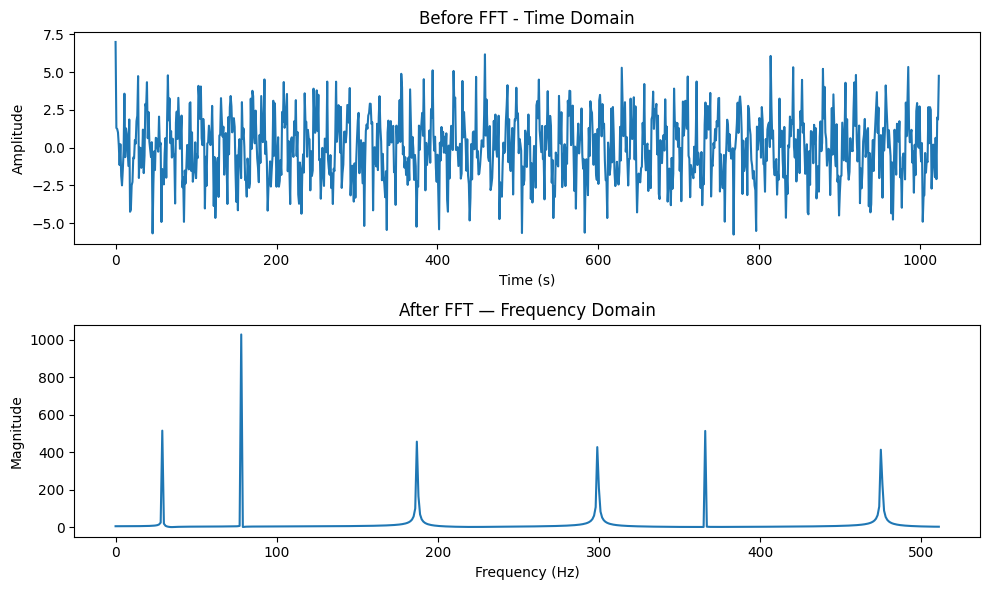

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

N  = 1024
fs = 1024

np.random.seed(42)
freqs  = np.random.uniform(0, 500, size=7)
n_idx  = np.arange(N)
signal = sum(np.cos(2.0 * np.pi * f * n_idx / N) for f in freqs)

t0     = time.perf_counter()
result = np.fft.fft(signal)
t1     = time.perf_counter()

print(f"Frequencies : {np.round(freqs, 2)}")
print(f"Time        : {(t1 - t0) * 1000:.3f} ms")
print(f"Throughput  : {N / (t1 - t0):,.1f} samples/sec")

fft_freqs = np.fft.fftfreq(N, d=1/fs)
magnitude = np.abs(result)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(n_idx, signal)
ax1.set_title(
    f"Before FFT - Time Domain"
)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")

ax2.plot(fft_freqs[:N//2], magnitude[:N//2])
ax2.set_title("After FFT — Frequency Domain")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import time

N = 1024
LOG2_N = 10


np.random.seed(42)
freqs = np.random.uniform(0, 500, size=1024)
n_idx = np.arange(N, dtype=np.float32)

signal = sum(np.cos(2.0 * np.pi * f * n_idx / N) for f in freqs).astype(np.float32)

x_real = signal.copy()
x_imag = np.zeros(N, dtype=np.float32)

t0 = time.perf_counter()

k_idx  = np.arange(N, dtype=np.float32)[:, None]
n_grid = np.arange(N, dtype=np.float32)[None, :]
angle  = -2.0 * np.pi * k_idx * n_grid / N

X_real = (x_real * np.cos(angle) - x_imag * np.sin(angle)).sum(axis=1)
X_imag = (x_real * np.sin(angle) + x_imag * np.cos(angle)).sum(axis=1)

t1 = time.perf_counter()

print("--- DFT Results ---")
print(f"Time : {(t1 - t0) * 1000:.3f} ms")
print(f"Throughput : {N / (t1 - t0):,.1f} samples/sec\n")

--- DFT Results ---
Time : 23.718 ms
Throughput : 43,174.4 samples/sec



In [ ]:
# Re-order the signal using bit-reversal
def bit_rev(x, b):
    r = 0
    for _ in range(b):
        r = (r << 1) | (x & 1)
        x >>= 1
    return r

rev_idx = np.array([bit_rev(n, LOG2_N) for n in range(N)], dtype=np.int32)


a = np.zeros(N, dtype=np.complex64)
a[rev_idx] = signal.astype(np.complex64)

t0_fft = time.perf_counter()

for s in range(1, LOG2_N + 1):
    m  = 1 << s
    m2 = m >> 1
    ang = -np.pi / np.float32(m2)

    twiddle    = np.exp(1j * ang * np.arange(m2, dtype=np.float32)).astype(np.complex64)
    num_groups = N // m

    u_idx = (np.arange(num_groups)[:, None] * m + np.arange(m2)[None, :]).ravel()
    v_idx = u_idx + m2
    tw    = np.tile(twiddle, num_groups)

    u_val = a[u_idx]
    v_val = a[v_idx] * tw
    a[u_idx] = u_val + v_val
    a[v_idx] = u_val - v_val

t1_fft = time.perf_counter()

print("--- FFT Results ---")
print(f"Time : {(t1_fft - t0_fft) * 1000:.3f} ms")
print(f"Throughput : {N / (t1_fft - t0_fft):,.1f} samples/sec")

--- FFT Results ---
Time : 1.819 ms
Throughput : 562,890.0 samples/sec
